# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries:

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (4)\car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Understand Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Check missing values:

In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

# Data Visualization
## Selling Price Distribution

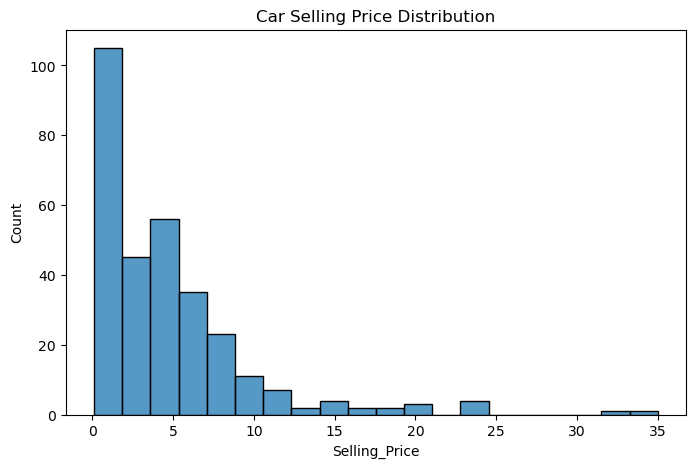

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], bins=20)
plt.title("Car Selling Price Distribution")
plt.show()

# Correlation Heatmap

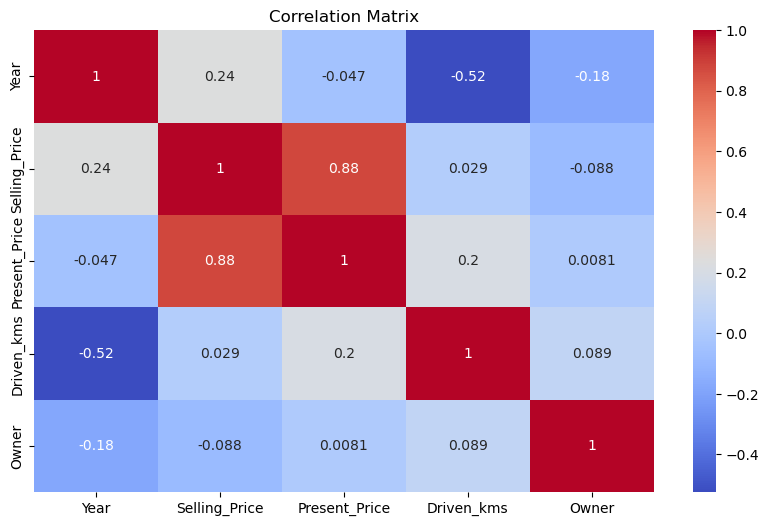

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Data Preprocessing

In [11]:
df = df.drop("Car_Name", axis=1)
df

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


# Convert categorical data:

In [12]:
df = pd.get_dummies(df, drop_first=True)
df

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,True,False,False,True
297,2015,4.00,5.90,60000,0,False,True,False,True
298,2009,3.35,11.00,87934,0,False,True,False,True
299,2017,11.50,12.50,9000,0,True,False,False,True


# Check dataset:

In [13]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


# Define Features and Target

In [14]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

# Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train, y_test

(     Year  Present_Price  Driven_kms  Owner  Fuel_Type_Diesel  \
 184  2008          0.750       26000      1             False   
 132  2017          0.950        3500      0             False   
 194  2008          0.787       50000      0             False   
 75   2015          6.800       36000      0             False   
 111  2016          1.500        8700      0             False   
 ..    ...            ...         ...    ...               ...   
 188  2013          0.570       18000      0             False   
 71   2011         12.480       45000      0              True   
 106  2014          3.450       16500      1             False   
 270  2011         10.000       69341      0             False   
 102  2017          1.780        4000      0             False   
 
      Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
 184              True                     True                 True  
 132              True                     True                 

# Train Model

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

model

LinearRegression()

# Prediction

In [18]:
y_pred = model.predict(X_test)
y_pred 

array([ 2.95433731,  8.17716341,  6.45612271, -1.42337164,  9.08864657,
        7.41793553,  1.33513921,  0.84032259,  1.36320242,  7.49067757,
        9.11623744,  0.58602147,  8.4171901 ,  3.42182892,  6.90176412,
        3.05018044,  0.4861294 , 10.7066932 ,  1.74950537,  2.34321858,
        0.3983127 ,  8.11856504,  6.62720292,  2.66249362,  0.78244173,
        3.69502798,  5.24822431,  2.82925881,  2.13370568,  1.75038508,
        0.39804532,  9.11715068, -0.65878346,  2.29562782,  8.5693085 ,
        4.49098276,  7.20461351,  7.54096855,  2.89153082,  7.9380318 ,
        3.94218138,  4.27826846,  4.33243831,  0.60013063,  7.34017047,
        0.47635371,  7.29115924, 11.23338227,  3.1391956 ,  5.38488332,
        6.80049399,  2.1763552 , 20.63141992, 16.99979702,  7.50636179,
        9.6950184 ,  4.47468976,  8.97255903,  1.82948926,  7.6037684 ,
        0.2226926 ])

# Model Evaluation

In [19]:
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8488707839191814
Mean Squared Error: 3.4813498305149064


# Visualization

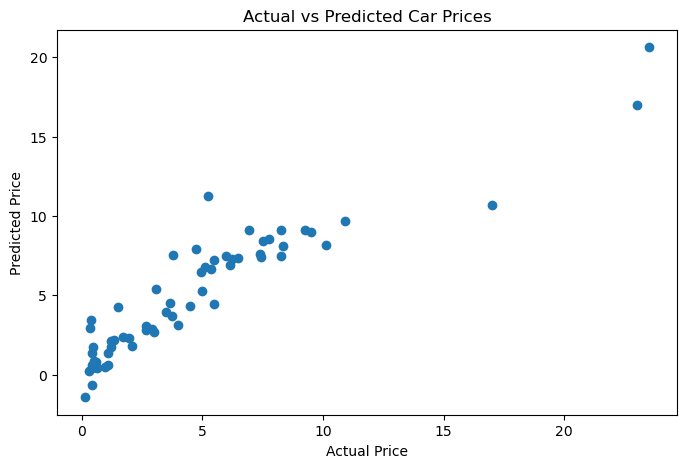

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# Markdown Conclusion

## Conclusion

A Linear Regression model was used to predict car prices.

Features like present price, fuel type, and car age influence the selling price.

The model shows good prediction capability.